# The pivot a director slices live

**Week 2, Friday. Round 1 of 3.** By the end of this notebook you can build the revenue tree by
segment as a pivot, say why the same pivot on the raw export shows nearly twice the revenue, prove
it with one count, and rebuild it so it reconciles to the warehouse to the rupee.

> **The client asks.** "Monday's growth review deck needs three things I can open on my laptop
> without a login: the revenue tree by segment for both quarters, the top-fifty protect list with a
> lookup so I can find any member by id, and one number on the front page with its trend."
>
> Meera's chief of staff, Kalpa Retail

> **Kavya's review.** "A pivot is only as honest as the rows under it. Before it reaches a director,
> its grand total matches Monday's warehouse number, or it does not leave the team."

Thursday ended on the customer table, one row per customer, exported as a CSV. This round opens that
table the way Excel does, pivots it, and then meets the other export the data team sent: the raw
one, one row per payment.

**Setup.** The helper, pandas, the two exports from `../data/`, and Monday's warehouse totals, which
are the control every number in this notebook is reconciled against. In Excel the same two files open
from the Codespace's file panel; nothing here is typed in.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

clean = pd.read_csv(kit.data_dir() / "C2_W02_D05_customer_table_STUDENT.csv")
raw = pd.read_csv(kit.data_dir() / "C2_W02_D05_raw_export_STUDENT.csv")
WAREHOUSE = {"Q1": 100_000_000, "Q2": 98_400_000}   # Monday's warehouse totals, from Week 2 Monday
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


def money(n):
    """Crore, lakh or rupees, whichever reads the size of the number, with the sign in front."""
    sign, a = ("-" if n < 0 else ""), abs(n)
    return sign + (crore(a) if a >= 1e7 else lakh(a) if a >= 1e5 else kit.rupees(round(a)))


print(len(clean), "customer rows and", len(raw), "export rows loaded")

300 customer rows and 1450 export rows loaded


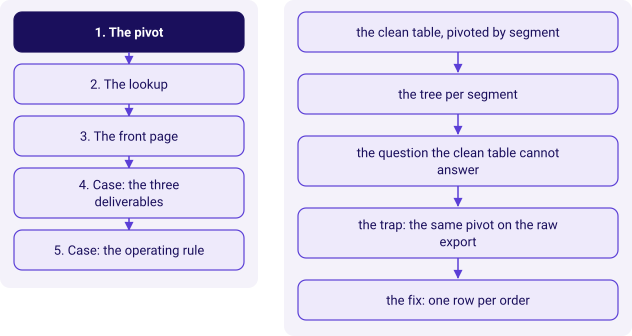

In [2]:
kit.side_by_side(
    kit.ladder(['The pivot', 'The lookup', 'The front page', 'Case: the three deliverables', 'Case: the operating rule'], lit=0, show=False),
    kit.vflow(['the clean table, pivoted by segment', 'the tree per segment', 'the question the clean table cannot answer', 'the trap: the same pivot on the raw export', 'the fix: one row per order'], show=False),
)

## 1. The clean table, pivoted by segment

The customer table has one row per customer, so a pivot with segment in Rows and revenue in Values
adds each customer once. In Excel: select the table, **Insert, PivotTable**, drag `segment` to Rows,
`revenue` to Values as Sum, `customer_id` to Values as Count, and `orders` as Sum.

**Predict before you run.** Which segment carries most of the revenue? a) Retail-Plus, the paid
tier; b) Retail-Core, the largest by customers; c) Business, the corporate buyers; d) no segment
carries more than a third.

Segment,Customers,Orders,Revenue
Business,39,188,"Rs 19,65,99,040"
Retail-Core,131,392,"Rs 7,39,320"
Retail-Plus,106,349,"Rs 9,77,410"
Student,24,65,"Rs 62,490"


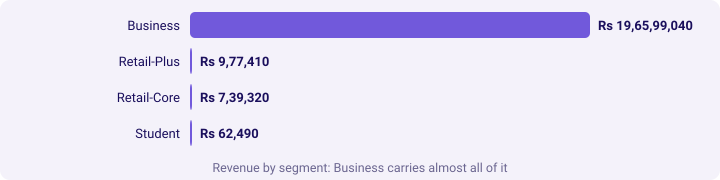

In [3]:
pivot = clean.pivot_table(index="segment", values=["customer_id", "orders", "revenue"],
                          aggfunc={"customer_id": "count", "orders": "sum", "revenue": "sum"})
pivot = pivot.rename(columns={"customer_id": "customers"})
kit.table(["Segment", "Customers", "Orders", "Revenue"],
          [(s, int(r.customers), int(r.orders), kit.rupees(r.revenue)) for s, r in pivot.iterrows()],
          caption="The clean customer table, pivoted by segment, both quarters together")
kit.bars([(s, int(r.revenue)) for s, r in pivot.sort_values("revenue", ascending=False).iterrows()],
         fmt=kit.rupees, title="Revenue by segment: Business carries almost all of it")

**What happened.** The answer is c. Business, 39 corporate buyers, carries about 99 percent of the
revenue, which is why a pivot's grand total is a Business number and why a consumer segment's
movement is invisible in it. Keep that in mind for the front page in round 3.

In [4]:
kit.check("the pivot holds one row per segment", len(pivot) == 4, f"{len(pivot)} rows")
kit.check("every customer is counted once", int(pivot.customers.sum()) == clean.customer_id.nunique(),
          f"{int(pivot.customers.sum())} customers")
kit.check("Business carries more than 95 percent of the revenue",
          pivot.revenue["Business"] / pivot.revenue.sum() > 0.95,
          f"{pivot.revenue['Business'] / pivot.revenue.sum():.1%}")

## 2. The tree, one segment at a time

The pivot gives the leaves of Week 1's tree per segment: customers, orders per customer and revenue
per order, which multiply back to revenue. In Excel these are two calculated columns beside the
pivot, `=orders/customers` and `=revenue/orders`, or a calculated field.

**Predict before you run.** Retail-Plus members buy bigger baskets than Retail-Core. Which leaf
explains most of the gap between the two segments' revenue per customer? a) customers; b) orders per
customer; c) revenue per order; d) the two segments are equal per customer.

Segment,Customers,Orders per customer,Revenue per order,Revenue per customer
Business,39,4.82,"Rs 10,45,740","Rs 50,41,001"
Retail-Core,131,2.99,"Rs 1,886","Rs 5,644"
Retail-Plus,106,3.29,"Rs 2,801","Rs 9,221"
Student,24,2.71,Rs 961,"Rs 2,604"


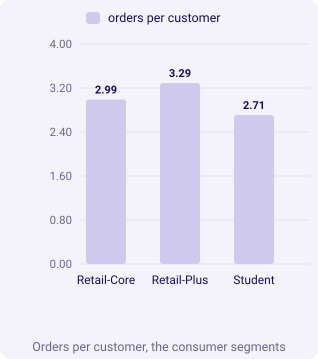

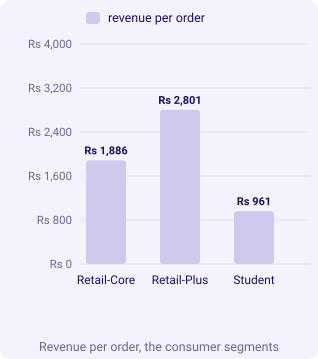

In [5]:
tree = pivot.assign(orders_per_customer=pivot.orders / pivot.customers,
                    revenue_per_order=pivot.revenue / pivot.orders)
tree["revenue_per_customer"] = tree.revenue / tree.customers
kit.table(["Segment", "Customers", "Orders per customer", "Revenue per order", "Revenue per customer"],
          [(s, int(r.customers), f"{r.orders_per_customer:.2f}", kit.rupees(round(r.revenue_per_order)),
            kit.rupees(round(r.revenue_per_customer))) for s, r in tree.iterrows()],
          caption="The leaves per segment, both quarters together")
consumer = ["Retail-Core", "Retail-Plus", "Student"]
kit.columns(consumer, [("orders per customer", [round(tree.orders_per_customer[s], 2) for s in consumer])],
            fmt=lambda v: f"{v:.2f}", title="Orders per customer, the consumer segments")
kit.columns(consumer, [("revenue per order", [round(tree.revenue_per_order[s]) for s in consumer])],
            fmt=kit.rupees, title="Revenue per order, the consumer segments")

**What happened.** The answer is c. Retail-Plus orders a little more often than Retail-Core (3.29
against 2.99) and pays about half as much again per order (Rs 2,801 against Rs 1,886), so the basket
does most of the work. The tree multiplies, so the check below multiplies it back.

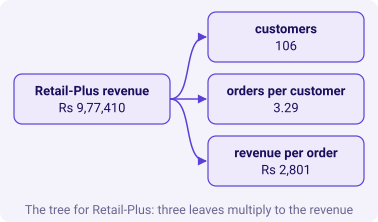

In [6]:
plus = tree.loc["Retail-Plus"]
kit.driver_tree({"label": "Retail-Plus revenue", "note": kit.rupees(plus.revenue), "children": [
    {"label": "customers", "note": f"{int(plus.customers)}"},
    {"label": "orders per customer", "note": f"{plus.orders_per_customer:.2f}"},
    {"label": "revenue per order", "note": kit.rupees(round(plus.revenue_per_order))}]},
    title="The tree for Retail-Plus: three leaves multiply to the revenue")
rebuilt = plus.customers * plus.orders_per_customer * plus.revenue_per_order
kit.check("the three leaves multiply back to the revenue", abs(rebuilt - plus.revenue) < 1,
          f"{kit.rupees(round(rebuilt))} against {kit.rupees(plus.revenue)}")
kit.check("Retail-Plus pays more per order than Retail-Core",
          tree.revenue_per_order["Retail-Plus"] > tree.revenue_per_order["Retail-Core"])

## 3. The question the clean table cannot answer

The chief of staff asked for the tree **for both quarters**. The customer table has a
`last_order_date` and a `revenue` summed across April to September, and no column that splits a
customer's revenue by quarter.

**Predict before you run.** Can the clean table give Q1 against Q2 by segment? a) yes, split on
`last_order_date`; b) yes, halve each customer's revenue; c) no, the split lives only at the order
grain; d) yes, since `orders` counts per quarter.

['customer_id', 'segment', 'city', 'orders', 'revenue', 'last_order_date']


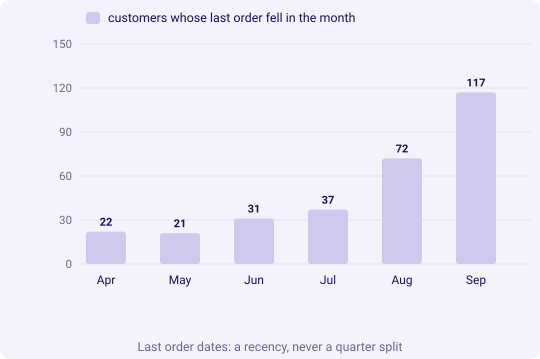

In [7]:
print(list(clean.columns))
months = pd.to_datetime(clean.last_order_date).dt.month
kit.columns(["Apr", "May", "Jun", "Jul", "Aug", "Sep"],
            [("customers whose last order fell in the month", [int((months == m).sum()) for m in range(4, 10)])],
            title="Last order dates: a recency, never a quarter split")

**What happened.** The answer is c. `last_order_date` says when a customer last bought, so splitting
on it would move a customer's whole two-quarter revenue into Q2 the moment they bought once in
September. Most customers last bought in Q2, so that split would invent a Q2 boom. The quarter split
needs the order grain, which only the raw export carries.

In [8]:
kit.check("the clean table carries no quarter column", "quarter" not in clean.columns and "order_date" not in clean.columns)
kit.check("most customers last bought in Q2, so a split on it would inflate Q2", (months >= 7).mean() > 0.5,
          f"{(months >= 7).mean():.0%} of customers")

## 4. The trap: the same pivot on the raw export

The raw export has an `order_date`, so the quarter split looks one drag away. Build the pivot the way
a hurried analyst does: quarter in Columns, segment in Rows, `order_amount` as Sum.

**The plausible wrong answer.**

In [9]:
raw["quarter"] = pd.to_datetime(raw.order_date).dt.month.map(lambda m: "Q1" if m <= 6 else "Q2")
hurried = raw.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum")
kit.table(["Segment", "Q1", "Q2", "Change"],
          [(s, kit.rupees(r.Q1), kit.rupees(r.Q2), f"{(r.Q2 - r.Q1) / r.Q1:+.1%}") for s, r in hurried.iterrows()]
          + [("All segments", kit.rupees(hurried.Q1.sum()), kit.rupees(hurried.Q2.sum()),
              f"{(hurried.Q2.sum() - hurried.Q1.sum()) / hurried.Q1.sum():+.1%}")],
          caption="The hurried pivot on the raw export: Sum of order_amount")
kit.stats([(crore(hurried.Q1.sum()), "Q1, as the pivot shows it", "the warehouse says Rs 10.00 crore"),
           (crore(hurried.Q2.sum()), "Q2, as the pivot shows it", "the warehouse says Rs 9.84 crore"),
           (f"{(hurried.Q2['Retail-Core'] - hurried.Q1['Retail-Core']) / hurried.Q1['Retail-Core']:+.1%}",
            "Retail-Core, Q1 to Q2", "the pivot says it grew")])

Segment,Q1,Q2,Change
Business,"Rs 19,80,28,880","Rs 19,34,72,200",-2.3%
Retail-Core,"Rs 4,33,760","Rs 4,38,160",+1.0%
Retail-Plus,"Rs 9,38,160","Rs 7,00,910",-25.3%
Student,"Rs 35,350","Rs 48,070",+36.0%
All segments,"Rs 19,94,36,150","Rs 19,46,59,340",-2.4%


**Why it is wrong.** The export holds one row per **payment**, and `order_amount` repeats on every
row of an order. An order paid in two instalments appears twice, and so does an order the gateway
posted twice, so the pivot adds each of those orders two times. In business terms: the deck would
put Rs 19.47 crore on Q2, nearly twice what Finance booked, and it would say Retail-Core grew 1.0
percent when it fell. A growth plan built on that leaves Core alone. The check is one count: rows
against distinct order ids, then the grand total against the warehouse.

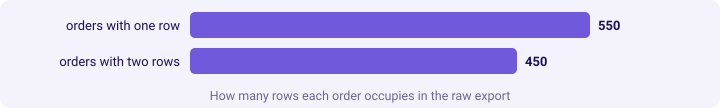

In [10]:
rows, orders = len(raw), raw.order_id.nunique()
kit.stats([(f"{rows:,}", "rows in the export", "one per payment"),
           (f"{orders:,}", "distinct orders", "what the warehouse holds"),
           (f"{rows / orders:.2f}", "rows per order", "anything above 1.00 inflates a Sum")])
per = raw.groupby("order_id").size()
kit.bars([("orders with one row", int((per == 1).sum())), ("orders with two rows", int((per == 2).sum()))],
         title="How many rows each order occupies in the raw export")
kit.check("the export carries more rows than orders", rows > orders, f"{rows} rows, {orders} orders")
kit.check("the hurried pivot does not reconcile to the warehouse",
          abs(hurried.values.sum() - sum(WAREHOUSE.values())) > 1,
          f"{crore(hurried.values.sum())} against {crore(sum(WAREHOUSE.values()))}")

**Excel's Remove Duplicates is not the fix.** The first instinct is **Data, Remove Duplicates** on
every column. Predict before you run: after it, what does the grand total read? a) Rs 19.84 crore,
the warehouse; b) still about Rs 39.4 crore; c) about half the warehouse; d) the tool refuses a file
with repeated ids.

In [11]:
deduped = raw.drop_duplicates()
kit.table(["Version of the export", "Rows", "Grand total"],
          [("as exported", len(raw), crore(raw.order_amount.sum())),
           ("after Remove Duplicates on every column", len(deduped), crore(deduped.order_amount.sum())),
           ("the warehouse", orders, crore(sum(WAREHOUSE.values())))],
          caption="Removing exact copies clears only the rows that are identical in every column")
kit.check("Remove Duplicates leaves more rows than orders", len(deduped) > orders, f"{len(deduped)} rows")

Version of the export,Rows,Grand total
as exported,1450,Rs 39.41 crore
after Remove Duplicates on every column,1400,Rs 39.41 crore
the warehouse,1000,Rs 19.84 crore


**What happened.** The answer is b. Remove Duplicates took out 50 rows, the copies identical in every
column, and left 1,400 rows, because an instalment's two rows differ in `paid_amount` and are not
duplicates. The total barely moved. The grain is the problem, and the fix names the grain.

**The fix.** Count each order once. In Excel, a helper column in the export,
`=IF(COUNTIF($A$2:A2,A2)=1,1,0)`, flags the first row of each order; the pivot then filters on it, or
a `SUMIFS` over it builds the tree. In pandas it is one line.

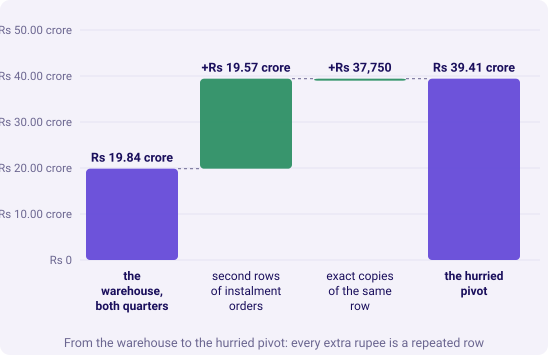

In [12]:
orders_once = raw.drop_duplicates("order_id")
fixed = orders_once.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum")
copies = int(raw.order_amount.sum() - deduped.order_amount.sum())
second_rows = int(raw.order_amount.sum() - orders_once.order_amount.sum()) - copies
kit.bridge(("the warehouse, both quarters", sum(WAREHOUSE.values())),
           [("second rows of instalment orders", second_rows),
            ("exact copies of the same row", copies)],
           end_label="the hurried pivot", fmt=money,
           title="From the warehouse to the hurried pivot: every extra rupee is a repeated row")
kit.check("the fixed pivot reconciles to the warehouse to the rupee",
          int(fixed.values.sum()) == sum(WAREHOUSE.values()), crore(fixed.values.sum()))
kit.check("Q2 lands on Monday's number", int(fixed.Q2.sum()) == WAREHOUSE["Q2"], crore(fixed.Q2.sum()))

**What changed.** The grand total falls from Rs 39.41 crore to Rs 19.84 crore, which is the
warehouse to the rupee, and Retail-Core turns from a 1.0 percent rise into a 1.8 percent fall. Every
segment moves, since instalment orders sit in every segment. Now the tree per quarter can be read.

Segment,Quarter,Customers,Orders per customer,Revenue per order,Revenue
Business,Q1,36,2.69,"Rs 10,20,767","Rs 9,90,14,440"
Business,Q2,35,2.60,"Rs 10,72,358","Rs 9,75,84,600"
Retail-Core,Q1,102,1.95,"Rs 1,875","Rs 3,73,070"
Retail-Core,Q2,96,2.01,"Rs 1,898","Rs 3,66,250"
Retail-Plus,Q1,91,2.36,"Rs 2,725","Rs 5,85,770"
Retail-Plus,Q2,76,1.84,"Rs 2,953","Rs 4,13,380"
Student,Q1,15,1.80,Rs 990,"Rs 26,720"
Student,Q2,20,1.90,Rs 941,"Rs 35,770"


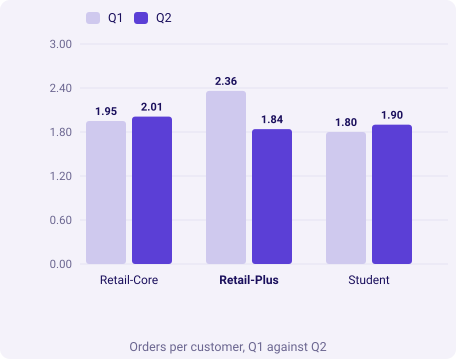

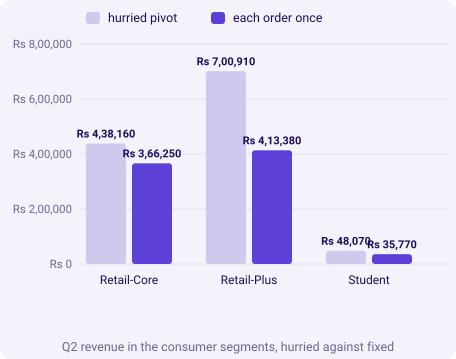

In [13]:
q = orders_once.groupby(["segment", "quarter"]).agg(customers=("customer_id", "nunique"),
                                                   orders=("order_id", "size"),
                                                   revenue=("order_amount", "sum"))
q["orders_per_customer"] = q.orders / q.customers
q["revenue_per_order"] = q.revenue / q.orders
kit.table(["Segment", "Quarter", "Customers", "Orders per customer", "Revenue per order", "Revenue"],
          [(s, qq, int(r.customers), f"{r.orders_per_customer:.2f}", kit.rupees(round(r.revenue_per_order)),
            kit.rupees(r.revenue)) for (s, qq), r in q.iterrows()],
          caption="The tree by segment and quarter, each order counted once")
kit.columns(consumer, [("Q1", [round(q.loc[(s, "Q1"), "orders_per_customer"], 2) for s in consumer]),
                       ("Q2", [round(q.loc[(s, "Q2"), "orders_per_customer"], 2) for s in consumer])],
            fmt=lambda v: f"{v:.2f}", lit=[1], title="Orders per customer, Q1 against Q2")
kit.columns(consumer, [("hurried pivot", [int(hurried.Q2[s]) for s in consumer]),
                       ("each order once", [int(fixed.Q2[s]) for s in consumer])],
            fmt=kit.rupees, title="Q2 revenue in the consumer segments, hurried against fixed")

In [14]:
kit.check("Retail-Core falls once each order is counted once", fixed.Q2["Retail-Core"] < fixed.Q1["Retail-Core"],
          f"{kit.rupees(fixed.Q1['Retail-Core'])} to {kit.rupees(fixed.Q2['Retail-Core'])}")
kit.check("Retail-Plus orders per customer fall from Q1 to Q2",
          q.loc[("Retail-Plus", "Q2"), "orders_per_customer"] < q.loc[("Retail-Plus", "Q1"), "orders_per_customer"],
          f"{q.loc[('Retail-Plus', 'Q1'), 'orders_per_customer']:.2f} to {q.loc[('Retail-Plus', 'Q2'), 'orders_per_customer']:.2f}")

**Your turn: reconcile the clean table too.** The tree now reconciles, and the protect list in round
2 will come from the clean customer table, so that table has to reconcile as well. Type these lines
into the empty cell below, run them, and say in one sentence what you find and what it means for the
list:

```python
print(clean.revenue.sum(), sum(WAREHOUSE.values()))
print(clean.orders.sum(), orders)
missing = set(orders_once.customer_id) - set(clean.customer_id)
print(missing)
```

> **Kavya's review.** "Two exports, two grains. The customer table is one row per customer and the
> raw export is one row per payment. Say the grain before you pivot, count rows against ids, and
> tie the grand total to Monday's number. A pivot that has not been reconciled has not been built."

### In the interview

**[F] Your pivot shows a different total from the warehouse. Where do you look first?** At the
grain. I count the rows under the pivot against the distinct keys the warehouse counts; if rows
outnumber keys, something repeats, usually a join or an export at a finer grain such as payments or
line items, and a Sum adds each repeat. Second, the filters and the period: a date window cut
differently, or a status the warehouse excludes. Third, what is missing: keys in the warehouse and
not in the sheet. Here the export had 1,450 rows for 1,000 orders; counting each order once brought
Rs 39.41 crore back to Rs 19.84 crore, the warehouse to the rupee.

**[S] SQL, pandas or Excel: how do you choose?** By who has to trust the number and how often it is
rebuilt. Anything Finance audits is computed where it can be reviewed and rerun: the warehouse, in
SQL. The analyst's exploration, rerun and changed daily, is pandas. The last mile, where a
stakeholder slices a finished table in a room, is Excel, fed from the warehouse's export and never
typed over.

### Depth: why a PivotTable needs a refresh

A PivotTable keeps its own cache of the source. Microsoft's own page says a PivotTable built on a
source "need[s] to be refreshed" when data is added (Create a PivotTable, verified 29 September 2026),
so a director who edits a source cell sees nothing move until somebody presses Refresh. A tree
written as `SUMIFS` over the export recalculates at once. The deck pack in `demos/` does it that way
for that reason.

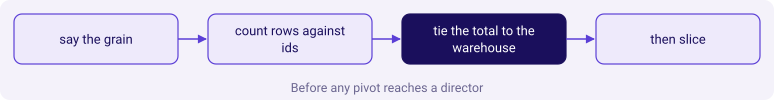

What this round established,The number
"the clean table, pivoted","one row per customer, 300 customers"
the hurried pivot on the raw export,"Rs 39.41 crore, 1,450 rows for 1,000 orders"
after Remove Duplicates,"Rs 39.41 crore, 1,400 rows"
each order counted once,"Rs 19.84 crore, the warehouse to the rupee"
Retail-Plus orders per customer,2.36 in Q1 to 1.84 in Q2


In [15]:
kit.flow(["say the grain", "count rows against ids", "tie the total to the warehouse", "then slice"],
         lit=2, title="Before any pivot reaches a director")
kit.table(["What this round established", "The number"],
          [("the clean table, pivoted", "one row per customer, 300 customers"),
           ("the hurried pivot on the raw export", "Rs 39.41 crore, 1,450 rows for 1,000 orders"),
           ("after Remove Duplicates", "Rs 39.41 crore, 1,400 rows"),
           ("each order counted once", "Rs 19.84 crore, the warehouse to the rupee"),
           ("Retail-Plus orders per customer", "2.36 in Q1 to 1.84 in Q2")])
kit.check_summary()

Round 2 takes the clean table to the protect list, and asks what a lookup should say when an id is
not there.